# S. aureus Survival with Wild-Type P. aeruginosa

This notebook analyzes the effect of spatial segregation patterns on *S. aureus* survival when co-cultured with wild-type *P. aeruginosa*.

## Dataset
- **Experimental design**: Checkerboard co-cultures with four spatial arrangements (mixed, small, medium, big)
- **Measurement**: *S. aureus* survival probability after 1h tobramycin treatment
- **Replicates**: 3 biological replicates
- **Strain**: Wild-type *P. aeruginosa*


In [9]:
import matplotlib.pyplot as plt
from scipy.stats import kruskal
import pandas as pd
import numpy as np
import os

# Load survival data from all three biological replicates
file_names = ['20251030.csv', '20251105.csv', '20251114.csv']

all_data = []
for i, fname in enumerate(file_names, start=1):
    df = pd.read_csv(fname)
    df_sa = df[(df['target'] == 'S. aureus') & (df['timepoint'] == 1)].copy()
    df_sa['replicate'] = i
    all_data.append(df_sa)
    print(f"✓ Loaded replicate {i}: {fname}")

# Combine replicates
survival_df = pd.concat(all_data, ignore_index=True)


# Map strain names to labels
partner_map = {
    'P. aeruginosa wt': 'wt',
    'P. aeruginosa ∆∆rhlApqsL': '∆∆',
    'P. aeruginosa pqsL+': 'HQNO+',
    'P. aeruginosa rhlAB+': 'RHL+'
}
survival_df['partner_label'] = survival_df['partner'].map(partner_map)

print(f"\n✓ Total observations: {len(survival_df)}")
print(f"✓ Checkerboard patterns: {sorted(survival_df['checkerboard'].unique())}")

✓ Loaded replicate 1: 20251030.csv
✓ Loaded replicate 2: 20251105.csv
✓ Loaded replicate 3: 20251114.csv

✓ Total observations: 48
✓ Checkerboard patterns: ['big', 'medium', 'mixed', 'small']


## Figure 5B: Wild-Type Survival Across Spatial Arrangements

Bar plot showing *S. aureus* survival probability when co-cultured with wild-type *P. aeruginosa* across four checkerboard patterns. Error bars represent standard deviation across biological replicates.

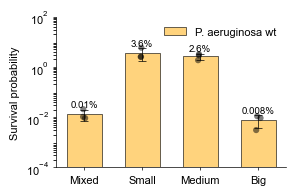


✓ Figure saved: 5B_survival_WT.pdf


In [10]:
# Set Chartosaur style
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'xtick.major.size': 2,
    'ytick.major.width': 0.5,
    'ytick.major.size': 2,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# Define checkerboard order
checker_order = ['mixed', 'small', 'medium', 'big']
color_map = {'wt': '#ffcc66'}

# Ensure checkerboard is categorical for ordering
survival_df['checkerboard'] = pd.Categorical(
    survival_df['checkerboard'], categories=checker_order, ordered=True
)

# Filter for wt only
survival_df_wt = survival_df[survival_df['partner_label'] == 'wt'].copy()

# Calculate mean and SD
summary_df = survival_df_wt.groupby(['partner_label', 'checkerboard']).agg(
    mean_survival=('survival', 'mean'),
    std_survival=('survival', lambda x: x.std(ddof=1))
).reset_index()

summary_df['mean_survival_pct'] = summary_df['mean_survival'] * 100
summary_df['std_survival_pct'] = summary_df['std_survival'] * 100

fig, ax = plt.subplots(figsize=(3, 2))

# Prepare data for plotting
x_vals = np.arange(len(checker_order))
df_p = summary_df.sort_values('checkerboard')
y = df_p['mean_survival_pct'].to_numpy()
yerr = df_p['std_survival_pct'].to_numpy()

# Plot bars
ax.bar(x_vals, y, width=0.6, color=color_map['wt'], alpha=0.85,
       edgecolor='black', linewidth=0.5, label='P. aeruginosa wt', zorder=2)

# Add error bars (standard deviation)
ax.errorbar(x_vals, y, yerr=yerr, fmt='none', capsize=3, capthick=0.5,
            elinewidth=0.5, ecolor='black', zorder=3)

# Overlay individual replicate measurements
for i, checker in enumerate(checker_order):
    replicate_vals = survival_df_wt[survival_df_wt['checkerboard'] == checker]['survival'].values * 100
    x_jitter = np.random.normal(0, 0.03, size=len(replicate_vals))
    x_positions = np.full(len(replicate_vals), x_vals[i]) + x_jitter
    ax.scatter(x_positions, replicate_vals, s=20, color='black', 
               alpha=0.5, zorder=4, edgecolor='none')

# Add percentage labels above error bars
for i, (x, y_val, y_err) in enumerate(zip(x_vals, y, yerr)):
    label_y = y_val + y_err * 1.2
    if y_val < 0.001:
        label = f'{y_val:.4f}%'
    elif y_val < 0.01:
        label = f'{y_val:.3f}%'
    elif y_val < 1:
        label = f'{y_val:.2f}%'
    else:
        label = f'{y_val:.1f}%'
    ax.text(x, label_y, label, ha='center', va='bottom', fontsize=7, color='black')

# Format axes
ax.set_xticks(x_vals)
ax.set_xticklabels([c.capitalize() for c in checker_order], fontsize=8)
ax.set_ylabel('Survival probability', fontsize=8)
ax.set_yscale('log')
ax.set_ylim(1e-4, summary_df['mean_survival_pct'].max() * 10)
ax.set_yticks([1e-4, 1e-2, 1e0, 1e2])

# Clean appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.grid(False)
ax.legend(frameon=False, fontsize=8, loc='upper right')

# Save and display
plt.tight_layout()
plt.savefig('5B_survival_WT.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved: 5B_survival_WT.pdf")

## Statistical Analysis: Effect of Spatial Arrangement

Kruskal-Wallis H-test to determine whether spatial segregation pattern significantly affects *S. aureus* survival when co-cultured with wild-type *P. aeruginosa*.

**Hypothesis**: Spatial arrangement has no effect on survival probability (H₀)

In [11]:
# Prepare data for analysis
checker_order = ['mixed', 'small', 'medium', 'big']
survival_df_wt = survival_df[survival_df['partner_label'] == 'wt'].copy()
survival_df_wt['log10_survival'] = np.log10(survival_df_wt['survival'] * 100)

# Statistical analysis

print("\n" + "="*80)
print("EFFECT OF SPATIAL ARRANGEMENT ON S. AUREUS SURVIVAL")
print("="*80)

# Display raw data
print("\nSurvival rates (%) by checkerboard pattern:")
for checker in checker_order:
    vals = survival_df_wt[survival_df_wt['checkerboard'] == checker]['survival'].values * 100
    print(f"  {checker:8s}: {vals[0]:.4f}, {vals[1]:.4f}, {vals[2]:.4f} "
          f"(mean = {np.mean(vals):.4f}%, SD = {np.std(vals, ddof=1):.4f}%)")

# ========================================
# KRUSKAL-WALLIS TEST
# ========================================

print("\n" + "="*70)
print("Kruskal-Wallis H-test")
print("H₀: Spatial arrangement has no effect on survival")
print("="*70)

# Prepare groups
groups = [
    survival_df_wt[survival_df_wt['checkerboard'] == checker]['log10_survival'].values
    for checker in checker_order
]

# Perform test
h_stat, p_value = kruskal(*groups)

print(f"\nH-statistic: {h_stat:.3f}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print(f"\n✓ Reject H₀: Spatial arrangement significantly affects survival (p < 0.05) *")
    sig_result = "SIGNIFICANT"
else:
    print(f"\n✗ Fail to reject H₀: No significant effect of spatial arrangement (p ≥ 0.05)")
    sig_result = "NOT SIGNIFICANT"

# ========================================
# DESCRIPTIVE PATTERN ANALYSIS
# ========================================

print("\n" + "="*70)
print("Descriptive Pattern")
print("="*70)

means_by_pattern = []
for checker in checker_order:
    vals = survival_df_wt[survival_df_wt['checkerboard'] == checker]['survival'].values * 100
    means_by_pattern.append(np.mean(vals))

print(f"\nSurvival is highest in: {checker_order[np.argmax(means_by_pattern)]}")
print(f"Survival is lowest in: {checker_order[np.argmin(means_by_pattern)]}")
print(f"Fold difference (max/min): {np.max(means_by_pattern) / np.min(means_by_pattern):.1f}×")

# Intermediate vs extreme comparison
intermediate_mean = np.mean([means_by_pattern[1], means_by_pattern[2]])  # small, medium
extreme_mean = np.mean([means_by_pattern[0], means_by_pattern[3]])  # mixed, big
print(f"\nIntermediate segregation (small/medium): {intermediate_mean:.4f}%")
print(f"Extreme segregation (mixed/big): {extreme_mean:.4f}%")
print(f"Ratio (intermediate/extreme): {intermediate_mean / extreme_mean:.1f}×")

# ========================================
# MANUSCRIPT TEXT
# ========================================

print("\n" + "="*80)
print("MANUSCRIPT REPORTING")
print("="*80)

print("\nMethods:")
print("""
"To assess whether spatial segregation pattern influences S. aureus survival 
during P. aeruginosa co-culture, survival rates across four checkerboard 
arrangements (mixed, small, medium, and large patches) were compared using 
the Kruskal-Wallis H-test on log₁₀-transformed survival percentages 
(n = 3 biological replicates per condition, α = 0.05)."
""")

print("Results:")
if p_value < 0.05:
    print(f"""
"Spatial arrangement significantly influenced S. aureus survival 
(Kruskal-Wallis H = {h_stat:.2f}, p = {p_value:.4f}). Intermediate segregation 
patterns (small and medium checkerboards) supported {intermediate_mean / extreme_mean:.1f}-fold 
higher survival (mean = {intermediate_mean:.4f}%) compared to fully mixed or 
fully segregated arrangements (mean = {extreme_mean:.4f}%)."
""")
else:
    print(f"""
"Spatial arrangement did not significantly affect S. aureus survival 
(Kruskal-Wallis H = {h_stat:.2f}, p = {p_value:.4f}), though intermediate 
segregation patterns showed numerically higher survival 
(mean = {intermediate_mean:.4f}%) than extreme patterns (mean = {extreme_mean:.4f}%)."
""")

# ========================================
# SUMMARY
# ========================================

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Overall effect of spatial arrangement: {sig_result}")
print(f"Kruskal-Wallis H = {h_stat:.3f}, p = {p_value:.4f}")
print(f"Biological pattern: Intermediate segregation promotes survival")
print(f"  Intermediate (small/medium): {intermediate_mean:.4f}%")
print(f"  Extremes (mixed/big): {extreme_mean:.4f}%")
print(f"  Ratio: {intermediate_mean / extreme_mean:.1f}×")


EFFECT OF SPATIAL ARRANGEMENT ON S. AUREUS SURVIVAL

Survival rates (%) by checkerboard pattern:
  mixed   : 0.0207, 0.0091, 0.0103 (mean = 0.0134%, SD = 0.0063%)
  small   : 5.8182, 2.5231, 2.5333 (mean = 3.6249%, SD = 1.8995%)
  medium  : 3.2000, 1.8526, 2.8941 (mean = 2.6489%, SD = 0.7064%)
  big     : 0.0109, 0.0092, 0.0031 (mean = 0.0077%, SD = 0.0041%)

Kruskal-Wallis H-test
H₀: Spatial arrangement has no effect on survival

H-statistic: 8.436
p-value: 0.0378

✓ Reject H₀: Spatial arrangement significantly affects survival (p < 0.05) *

Descriptive Pattern

Survival is highest in: small
Survival is lowest in: big
Fold difference (max/min): 468.4×

Intermediate segregation (small/medium): 3.1369%
Extreme segregation (mixed/big): 0.0106%
Ratio (intermediate/extreme): 297.2×

MANUSCRIPT REPORTING

Methods:

"To assess whether spatial segregation pattern influences S. aureus survival 
during P. aeruginosa co-culture, survival rates across four checkerboard 
arrangements (mixed, smal